<a href="https://colab.research.google.com/github/xz3468-gif/Canadian-immigration-policy_intro-to-text-analysis/blob/main/Characteristics_of_Canadian_immigration_policies_(final_version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Characteristics of Canadian Immigration Policy to Refugees in Global Conflicts

## 1. Introduction

As a country built on immigration, Canada has maintained a relatively welcoming approach to newcomers even as many parts of the world have shifted toward more restrictive and right-leaning policies. Canada is often regarded as a global leader in immigration policy, not only because immigration is widely seen as part of its national identity, but also because it is considered essential for supporting long-term economic development ( [Banerjee, Alboim, et al., 2025](https://https://www.migrationpolicy.org/article/canada-immigration-policy-inflection-point)).

One long-standing feature of Canada’s immigration system is its ability to respond quickly to major global conflicts, including wars, political crises, and other forms of instability. For example, after the 2019 Hong Kong protests, Canada introduced special measures to support Hong Kong residents who faced increasing restrictions under the CPC government.

Facing continuous policy adjustments, IRCC, Immigration, Refugees and Citizenship Canada,  plays a central role as the federal department responsible for managing immigration, refugee protection, and citizenship matters. On its official website, IRCC not only handles residency and visa applications but also maintains a dedicated Newsroom that provides real-time updates on policy changes and government announcements. Because this research aims to analyze how the Canadian government officially interprets and communicates its immigration priorities, IRCC’s Newsroom serves as the primary source for the text analysis used in this study.

This project seeks to address the following research questions:


## 1.1 Research questions

1. How does the prominence of humanitarian discourse in IRCC’s official news releases fluctuate in response to important global conflicts (e.g., the 2019 Hong Kong protests, the Afghanistan crisis) between 2019 and 2025?
2. When analyzing IRCC's news releases concerning refugee resettlement, what are the most frequently emphasized policy components (e.g., housing, employment, community integration, funding)?


### 1.2 Discussions and Literature Review

Before conducting the text analysis, it is important to review existing discussions on how Canada’s immigration system responds to global conflicts. At the social level, a 2025 survey by the Environics Institute shows that most Canadians still hold positive attitudes toward refugees' immigration ([Statista, 2025](https://www.statista.com/statistics/788949/opinion-on-migrant-levels-in-canada/)). About half of respondents disagreed that Canada admits “too many” immigrants, and many viewed immigration as essential for economic growth and population sustainability. ([Environics Institute, 2024](https://www.environicsinstitute.org/docs/default-source/default-document-library/final-report94fae631-0284-4ba5-b06a-e0aeeab5daf3.pdf?sfvrsn=9f47b717_1)). These views also contribute to general public openness toward accepting refugees, as many Canadians continue to link national identity with multiculturalism and inclusiveness ([Miekus, 2021](https://www.cicnews.com/2021/11/canadians-remain-largely-supportive-of-immigration-new-survey-finds-1119585.html#gs.tk26nl)).

From a policy perspective, Canada has long supported the UN Global Compacts on Migration and Refugees and often responds quickly to major global crises. However, its resettlement practices are not uniform. Canada tends to prioritize certain conflicts or groups. For instance, although the government committed to resettling 40,000 Afghan refugees after the Taliban takeover in 2021, actual arrivals were much slower than expected. By contrast, Canada moved rapidly to provide temporary protection to Ukrainians after Russia’s 2022 invasion. These differences reveal a selective pattern in Canada’s humanitarian response ([Atak, Kim, 2023](https://academic.oup.com/rsq/article/42/4/453/7284369?login=false)).

There’s a scholar who has criticized this selectivity, arguing that Canadian policy sometimes privileges refugees with particular religious, regional, or social backgrounds over others ([Kainz, Banulescu-bogdan, et.al., 2020](https://www.migrationpolicy.org/sites/default/files/publications/mpi-global-compacts-migration-refugees_final.pdf)). Limited domestic engagement may stem from government claims of compliance with the Global Compacts while bureaucratic inefficiencies and administrative barriers continue to restrict practical implementation.

In addition, Canada’s immigration policy is also shaped by its close relationship with the United States. The two countries have long cooperated to manage the movement of people and goods across their shared border and implemented the Safe Third Country Agreement. During Donald Trump’s two presidential terms, stricter U.S. immigration measures placed greater pressure on Canada’s asylum system.  ([Roy, Cheatham, 2025](https://www.cfr.org/backgrounder/what-canadas-immigration-policy)). Also, the Canadian government shows a limited opening attitude towards Gaza refugees, solely allowing Gaza citizens who have Canadian relatives to apply.

### 1.3 Significance to Policy Analysis

The significance of this research lies in its ability to use text analysis—supported by IT-TDF data visualization—to examine how the prominence of humanitarian terms in IRCC news releases, such as “refugees,” fluctuates in response to major global conflicts. This allows for a direct observation of the Canadian government’s selective focus in its official narrative and the extent to which its messaging may be shaped by geopolitical factors.

Additionally, the analysis can identify the key components of refugee resettlement policy emphasized in IRCC’s official communication. These frequently appearing terms reflect which aspects of resettlement the federal government views as most important. For example, if housing or employment is repeatedly highlighted, it may indicate greater political attention or resource allocation to these areas. Conversely, if other crucial components—such as mental health support—are not emphasized and are also lacking in practice, the findings can help signal to policymakers that official discourse and resource distribution may need to shift toward these overlooked areas.

## 2. Research Method

The research methodology will collect the official discourse of Immigration, Refugees and Citizenship Canada (IRCC) from 2019 to 2025. Because no public API is available for reaching to important news websites like CBC News, IRCC is the best choice as it's an official website for explaining newest immigration policies.
All IRCC news releases were collected through **web-scraping** and organized into a data frame to form the data corpus. The analysis is conducted in two stages.

First, **TF-IDF** is calculated and visualized over time to observe how the prominence of humanitarian changes in response to major global conflicts through **temporal line charts**. Second, a sub-corpus of articles specifically related to “resettlement” is extracted. A **word-cloud** is then applied to this sub-corpus to identify the policy components most frequently emphasized in IRCC’s official communication, such as housing, employment, or funding.

## 3. Text Analysis Coding Steps

### 3.1 Data Collection & Data Cleaning

In [ ]:
# install packages:
!pip install requests pandas beautifulsoup4 lxml python-dotenv

# Imports used throughout the workbook
import requests
import json
import pandas as pd
from bs4 import BeautifulSoup
import time
import os

In [ ]:
#Set a user-agent header to look like a browser.
headers = {
     "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
                 "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}

In [ ]:
#Perform news scraping from IRCC Newsroom and extract the result into a Pandas dataframe
ircc_list = []
article_count = 0

for page_number in (0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250,260,270,280,290,300,310,320):
  ircc_url = "https://www.canada.ca/en/news/advanced-news-search/news-results.html?start=2015-01-01&typ=newsreleases&end=&idx={}&dprtmnt=departmentofcitizenshipandimmigration".format(page_number)
  response = requests.get(ircc_url,headers=headers,timeout=20)
  soup = BeautifulSoup(response.text, 'html.parser')

# Looking for div with data-component='search-result'
  for news_item in soup.find_all('article',class_='item'):

    news_title = news_item.find('a').text
    news_link = news_item.find('a',href=True).get('href')
    news_time = news_item.find('time').get('datetime')

# Perform basic clean text.
    news_time = news_time.replace('·', '').strip()
    news_title = news_title.replace('•', '').strip()
    ircc_list.append([news_title, news_link, news_time])

ircc_news_df = pd.DataFrame(ircc_list, columns=['Title','Link','Time'])

# Display the header of the dataframe
ircc_news_df.head()

,Title,Link,Time
0,Canada invests in Francophone communities and ...,https://www.canada.ca/en/immigration-refugees-...,2025-11-27
1,Canada lifts the visa requirement for Qatari c...,https://www.canada.ca/en/immigration-refugees-...,2025-11-25
2,Canada reaches important milestone in restorin...,https://www.canada.ca/en/immigration-refugees-...,2025-11-21
3,Canada’s new Climate Competitiveness Strategy,https://www.canada.ca/en/immigration-refugees-...,2025-11-09
4,Canada extends temporary measures for Palestin...,https://www.canada.ca/en/immigration-refugees-...,2025-08-01


The following part includes data cleaning.

The project will investigate the keyword "refugees", while if only extract text by "div", the full name of IRCC will always appear at the begining of the scraped source, thus disturbing the text analysis. Therefore, relative data cleaning is important.

In [ ]:
# Scrape text from collected article links: define the scraping action first
def get_article_text_from_link(row):

 # Choose a URL to scrape: try the live df first, fallback to offline_df if needed.
 article_url = row['Link']

 try:
  # Send a GET request to retrieve the raw HTML of the page.
  page_resp = requests.get(article_url, timeout=15)

  # Create a BeautifulSoup object to parse the HTML document.
  soup_text = BeautifulSoup(page_resp.text, "html.parser")

  # Find all paragraph tags <div> and extract text from each to avoid the disturb from source text of "Immigration, Refugees, and Citizenship Canada"
  ircc_content = soup_text.find_all('div', class_='cmp-text')
  if not ircc_content:
    return 'CONTENT_NOT_FOUND'

  #Clean the datetime text in full text to avoid repeating the datetime, which will influence the scrape of other words
  for tag in ircc_content[0].find_all('strong'):
      tag.decompose()

  ircc_content_paragraphs = ircc_content[0].find_all('p')


  # Use a list comprehension to strip whitespace and only keep non-empty paragraphs.
  para_text = [row.get_text(strip=True) for row in ircc_content_paragraphs if row.get_text(strip=True)]

  # Join paragraphs into a single string for quick inspection.
  full_text = " ".join(para_text)
  print("First 500 characters of extracted text:\n")
  print(full_text[:500])

  return full_text

 except Exception as e:
  print("Error fetching:", e)
  text.append("")

In [ ]:
#Add scraped text as a new column aligned to the first N rows:
ircc_news_df=ircc_news_df.copy()
ircc_news_df.loc[:,"Full_Text"]=ircc_news_df.apply(get_article_text_from_link,axis=1)
ircc_news_df.head()

# Display the first few entries of the new column to confirm creation
for i, text in enumerate(ircc_news_df['Full_Text'].head()):
    if text is not None:
        print(f"Article {i}: {text[:500]}...")
    else:
        print(f"Article {i}: CONTENT_NOT_FOUND")


First 500 characters of extracted text:

– As announced in Budget 2025, the Government of Canada wants to focus immigration where it delivers the greatest impact to fill labour gaps, strengthen key economic sectors and support communities across the country. This includes prioritizing Francophone immigration outside Quebec, helping to enhance the vitality of Francophone and Acadian minority communities, and making the country more attractive to the world’s top Francophone and bilingual talents. Today, the Honourable Lena Metlege Diab, 
First 500 characters of extracted text:

The Honourable Lena Metlege Diab, Minister of Immigration, Refugees and Citizenship today announced that Canada has lifted the visa requirement for citizens of Qatar. This change took effect this morning at 5:30 a.m. EST. Introducing visa-free travel for Qatari citizens makes it faster and easier for travellers to visit Canada for business or leisure. This milestone underscores the strength of our bilateral cooper

In [ ]:
#Check the dataframe
ircc_news_df.head()

,Title,Link,Time,Full_Text
0,Canada invests in Francophone communities and ...,https://www.canada.ca/en/immigration-refugees-...,2025-11-27,"– As announced in Budget 2025, the Government ..."
1,Canada lifts the visa requirement for Qatari c...,https://www.canada.ca/en/immigration-refugees-...,2025-11-25,"The Honourable Lena Metlege Diab, Minister of ..."
2,Canada reaches important milestone in restorin...,https://www.canada.ca/en/immigration-refugees-...,2025-11-21,——Canada has taken an important step toward mo...
3,Canada’s new Climate Competitiveness Strategy,https://www.canada.ca/en/immigration-refugees-...,2025-11-09,Climate action is not only a moral responsibil...
4,Canada extends temporary measures for Palestin...,https://www.canada.ca/en/immigration-refugees-...,2025-08-01,Canada remains deeply concerned about the rapi...


### 3.2 Data Analysis: IF-TDF

In [ ]:
# In a fresh runtime (Runtime → Restart runtime), run:
!pip -q install "numpy==2.0.2" "scipy==1.14.1" "scikit-learn>=1.4"
!pip install nltk==3.9.2

import numpy, scipy, sklearn
print("NumPy:", numpy.__version__)     # → 2.0.2
print("SciPy:", scipy.__version__)     # → 1.14.x
print("sklearn:", sklearn.__version__) # ≥ 1.4


import nltk
nltk.download('inaugural')
nltk.download('stopwords')
nltk.download('punkt')

print("✅ Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.9 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
NumPy: 2.0.2
SciPy: 1.14.1
sklearn: 1.6.1


[nltk_data] Downloading package inaugural to /root/nltk_data...
[nltk_data]   Unzipping corpora/inaugural.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Setup complete.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import inaugural, stopwords
from nltk import word_tokenize, FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, LatentDirichletAllocation


# Display all rows and columns (adjust numbers as needed)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Show full text in each cell (no truncation)
pd.set_option('display.max_colwidth', None)

# Expand the display width so wide tables don't wrap
pd.set_option('display.width', 0)

print("✅ Pandas display options set for full view.")

print("✅ Imports loaded.")


✅ Pandas display options set for full view.
✅ Imports loaded.


In [ ]:
tfidf = TfidfVectorizer(min_df=2)

X_tfidf = tfidf.fit_transform(ircc_news_df['Full_Text'])

terms = np.array(tfidf.get_feature_names_out())

X_tfidf.shape, len(terms)

((330, 3174), 3174)

In [ ]:
def top_tfidf_terms_for_doc(document_index, top_n=12): #Define a function that returns the top-n TF–IDF terms for a single document (speech).
  tfidf_scores = X_tfidf[document_index, :]

  sorted_indices = np.argsort(tfidf_scores.toarray().flatten())[::-1]
  top_n_indices = sorted_indices[:top_n]

  top_keywords = terms[top_n_indices]
  top_scores = tfidf_scores.toarray().flatten()[top_n_indices]

  return list(zip(top_keywords, top_scores))

# Moved the printing loop outside the function definition
for i in [0, X_tfidf.shape[0]//2, X_tfidf.shape[0]-1]:
    print(f"\n--- Top TF-IDF terms for Document {i} ---")
    for term, score in top_tfidf_terms_for_doc(i, top_n=12): #Calls the function to get the top 12 terms for that document
        print(f"{term:15s} {score:.3f}")


--- Top TF-IDF terms for Document 0 ---
francophone     0.388
the             0.312
of              0.210
to              0.190
promotion       0.184
activities      0.183
2025            0.175
and             0.174
bilingual       0.161
review          0.153
budget          0.125
communities     0.122

--- Top TF-IDF terms for Document 165 ---
mirps           0.349
the             0.262
mexico          0.206
and             0.206
of              0.196
protection      0.179
forcibly        0.168
displacement    0.159
america         0.148
platform        0.148
central         0.142
displaced       0.126

--- Top TF-IDF terms for Document 329 ---
winners         0.283
employer        0.263
the             0.253
and             0.220
newcomers       0.195
awards          0.189
summit          0.179
local           0.161
ottawa          0.152
employment      0.152
to              0.152
connections     0.149


**3.2.1** The Temporal Line Chart Analysis

Use **temporal line chart** based on picked keywords to analyze data through time.

As the horizontal axis is crowded by the news date, it's divided into 8 parts to simplify.

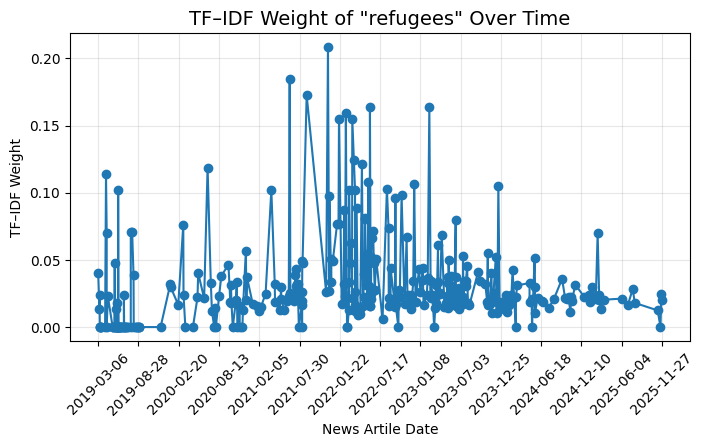

In [ ]:
# Create a temporal line chart by the word "refugees" to test the Canadian government's response towards global politics
term = "refugees"

if term in terms:
    term_idx = np.where(terms == term)[0][0]
    ircc_news_df[f"tfidf_{term}"] = X_tfidf[:, term_idx].toarray().ravel()

    # Convert 'Time' column to datetime objects
    ircc_news_df['Time'] = pd.to_datetime(ircc_news_df['Time'])

    plt.figure(figsize=(8,4))
    plt.plot(ircc_news_df['Time'], ircc_news_df[f"tfidf_{term}"], marker='o', linestyle='-')
    plt.title(f'TF–IDF Weight of "{term}" Over Time', fontsize=14)
    plt.xlabel("News Artile Date")
    plt.ylabel("TF–IDF Weight")

# Simplify the horizontal axis and divide it into 15 equal parts
    earliest_date = ircc_news_df['Time'].min()
    latest_date = ircc_news_df['Time'].max()

# Create 8 equally spaced timestamps between earliest_date and latest_date
    x_ticks_space = pd.date_range(start=earliest_date, end=latest_date, periods=15)

# Name back the timestamps by datetime
    x_ticks_dates = pd.to_datetime(x_ticks_space)

# Apply the transformation to x-axis (this code was generated by Google Colab automatically)
    plt.xticks(x_ticks_dates, rotation=45)

    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f'Term "{term}" not found in vocabulary. Try another word.')

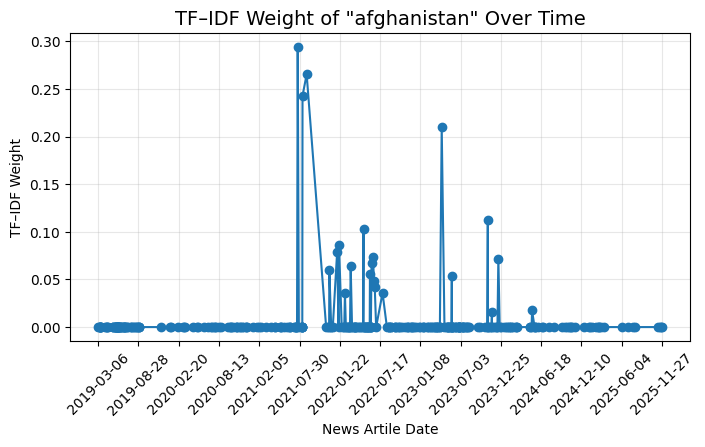

In [ ]:
# Create a temporal line chart by the word "afghanistan" to test its reponse towards Taliban takeover
term = "afghanistan"

if term in terms:
    term_idx = np.where(terms == term)[0][0]
    ircc_news_df[f"tfidf_{term}"] = X_tfidf[:, term_idx].toarray().ravel()

    # Convert 'Time' column to datetime objects
    ircc_news_df['Time'] = pd.to_datetime(ircc_news_df['Time'])

    plt.figure(figsize=(8,4))
    plt.plot(ircc_news_df['Time'], ircc_news_df[f"tfidf_{term}"], marker='o', linestyle='-')
    plt.title(f'TF–IDF Weight of "{term}" Over Time', fontsize=14)
    plt.xlabel("News Artile Date")
    plt.ylabel("TF–IDF Weight")

# Simplify the horizontal axis and divide it into 15 equal parts
    earliest_date = ircc_news_df['Time'].min()
    latest_date = ircc_news_df['Time'].max()

# Create 8 equally spaced timestamps between earliest_date and latest_date
    x_ticks_space = pd.date_range(start=earliest_date, end=latest_date, periods=15)

# Name back the timestamps by datetime
    x_ticks_dates = pd.to_datetime(x_ticks_space)

# Apply the transformation to x-axis (this code was generated by Google Colab automatically)
    plt.xticks(x_ticks_dates, rotation=45)

    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f'Term "{term}" not found in vocabulary. Try another word.')

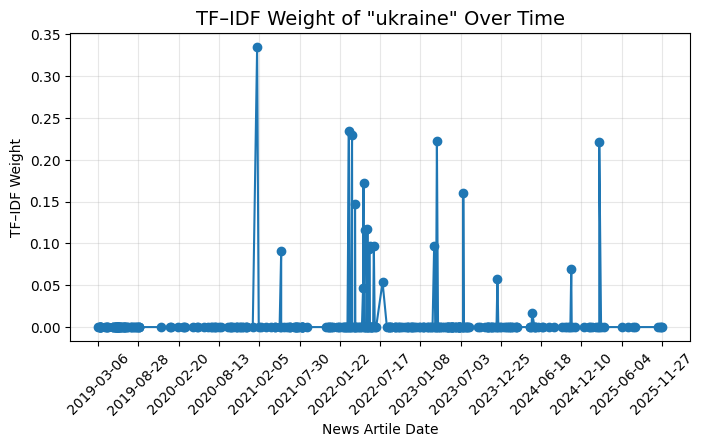

In [ ]:
# Create a temporal line chart by the word "ukraine" to test its reponse towards Russia's invasion
term = "ukraine"

if term in terms:
    term_idx = np.where(terms == term)[0][0]
    ircc_news_df[f"tfidf_{term}"] = X_tfidf[:, term_idx].toarray().ravel()

    # Convert 'Time' column to datetime objects
    ircc_news_df['Time'] = pd.to_datetime(ircc_news_df['Time'])

    plt.figure(figsize=(8,4))
    plt.plot(ircc_news_df['Time'], ircc_news_df[f"tfidf_{term}"], marker='o', linestyle='-')
    plt.title(f'TF–IDF Weight of "{term}" Over Time', fontsize=14)
    plt.xlabel("News Artile Date")
    plt.ylabel("TF–IDF Weight")

# Simplify the horizontal axis and divide it into 15 equal parts
    earliest_date = ircc_news_df['Time'].min()
    latest_date = ircc_news_df['Time'].max()

# Create 8 equally spaced timestamps between earliest_date and latest_date
    x_ticks_space = pd.date_range(start=earliest_date, end=latest_date, periods=15)

# Name back the timestamps by datetime
    x_ticks_dates = pd.to_datetime(x_ticks_space)

# Apply the transformation to x-axis (this code was generated by Google Colab automatically)
    plt.xticks(x_ticks_dates, rotation=45)

    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f'Term "{term}" not found in vocabulary. Try another word.')

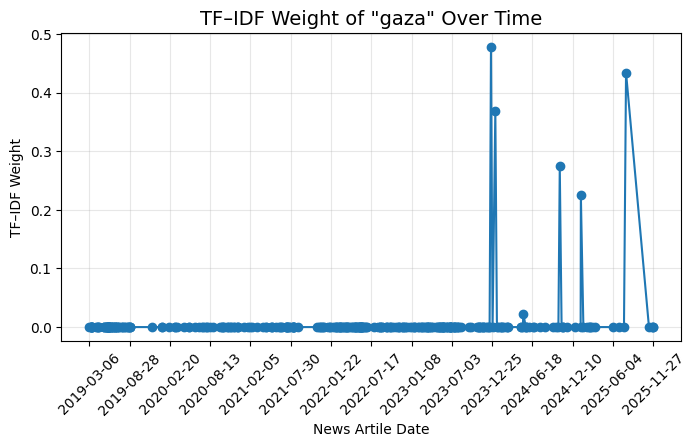

In [ ]:
# Create a temporal line chart by the word "gaza" to test its reponse towards the war in Gaza
term = "gaza"

if term in terms:
    term_idx = np.where(terms == term)[0][0]
    ircc_news_df[f"tfidf_{term}"] = X_tfidf[:, term_idx].toarray().ravel()

    # Convert 'Time' column to datetime objects
    ircc_news_df['Time'] = pd.to_datetime(ircc_news_df['Time'])

    plt.figure(figsize=(8,4))
    plt.plot(ircc_news_df['Time'], ircc_news_df[f"tfidf_{term}"], marker='o', linestyle='-')
    plt.title(f'TF–IDF Weight of "{term}" Over Time', fontsize=14)
    plt.xlabel("News Artile Date")
    plt.ylabel("TF–IDF Weight")

# Simplify the horizontal axis and divide it into 15 equal parts
    earliest_date = ircc_news_df['Time'].min()
    latest_date = ircc_news_df['Time'].max()

# Create 8 equally spaced timestamps between earliest_date and latest_date
    x_ticks_space = pd.date_range(start=earliest_date, end=latest_date, periods=15)

# Name back the timestamps by datetime
    x_ticks_dates = pd.to_datetime(x_ticks_space)

# Apply the transformation to x-axis (this code was generated by Google Colab automatically)
    plt.xticks(x_ticks_dates, rotation=45)

    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f'Term "{term}" not found in vocabulary. Try another word.')

**3.2.2** The Wordcloud Analysis of refugees' resettlement

**Data cleaning**: Firstly, we need to create a new dataframe in which all its texts include "resettlement".

In [ ]:
# Choose the keyword for selection
keyword = r'resettlement'

# Create a new dataframe by filtering for rows where 'Full_Text' contains the keyword
resettlement_ircc_df = ircc_news_df[ircc_news_df['Full_Text'].str.contains(keyword, na=False)].copy()

In [ ]:

EN_STOP = set(stopwords.words('english'))

CUSTOM_STOP = {
  'refugees','across','the','one','times','also','canada','better','refugee','explore','members','pakistan','people','countries'
}

STOPWORDS = EN_STOP.union(CUSTOM_STOP)

def simple_clean_tokens(text):
    """
    1) Lowercase
    2) Tokenize
    3) Keep alphabetic tokens of length >= 3
    4) Remove stopwords
    """
    text = text.lower()
    tokens = word_tokenize(text)
    clean = [tok for tok in tokens if tok.isalpha() and len(tok) >= 3 and tok not in STOPWORDS]
    return clean

resettlement_ircc_df['Full_Text'] = resettlement_ircc_df['Full_Text'].apply(simple_clean_tokens)
resettlement_ircc_df.head()


/tmp/ipython-input-3867554624.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resettlement_ircc_df['Full_Text'] = resettlement_ircc_df['Full_Text'].apply(simple_clean_tokens)


,Title,Link,Time,Full_Text,tfidf_refugees,tfidf_afghanistan,tfidf_ukraine,tfidf_gaza
51,Canada builds on pledges and partnerships at the Global Refugee Forum,https://www.canada.ca/en/immigration-refugees-citizenship/news/2023/12/canada-builds-on-pledges-and-partnerships-at-the-global-refugee-forum.html,2023-12-15,"[globe, million, forcibly, displaced, homes, third, response, vast, humanitarian, need, shares, responsibility, step, take, action, continue, leading, example, offering, protection, vulnerable, populations, supporting, host, creating, opportunities, beyond, resettlement, pathways, week, honourable, marc, miller, minister, immigration, citizenship, led, delegation, global, forum, geneva, building, previous, commitments, presented, endorsed, number, pledges, advance, solutions, global, crisis, building, recent, work, towelcome, vulnerable, afghans, achieved, exceeded, minister, announced, million, international, organization, migration, iom, support, vulnerable, afghan, populations, central, asia, fleeing, afghanistan, funding, help, neighbouring, become, equipped, support, respond, needs, minister, miller, highlighted, plans, resettle, next, years, continue, offerprotection, world, vulnerable, including, women, precarious, situations, ethnic, religious, ...]",0.105335,0.071946,0.0,0.0
58,National Settlement and Resettlement Funding Call for Proposals Now Accepting Applications,https://www.canada.ca/en/immigration-refugees-citizenship/news/2023/11/national-settlement-and-resettlement-funding-call-for-proposals-now-accepting-applications.html,2023-11-15,"[government, committed, ensuring, eligible, newcomers, support, services, need, succeed, fully, integrating, contributing, canadian, economy, new, communities, yesterday, honourable, marc, miller, minister, immigration, citizenship, launched, national, settlement, resettlement, funding, call, proposals, fund, hundreds, settlement, resettlementservice, provider, organizationsacross, outside, quebec, provide, critical, services, newcomers, funding, agreements, period, five, years, year, call, proposals, highlights, key, areas, settlement, resettlement, services, including, investments, support, truth, reconciliation, objectives, provide, francophone, integration, pathway, newcomers, outside, quebec, enhancing, programming, funding, organizations, serve, racialized, communities, underrepresented, build, recent, lessons, advancements, leveraging, technology, partnerships, deliver, services, efficiently, maintaining, high, quality, support, clients, service, provider, organizations, play, pivotal, role, welcoming, newcomers, ...]",0.040522,0.000000,0.0,0.0
62,"Canada meets commitment to welcome 40,000 vulnerable Afghans",https://www.canada.ca/en/immigration-refugees-citizenship/news/2023/10/canada-meets-commitment-to-welcome-40000-vulnerable-afghans.html,2023-10-30,"[government, longstanding, proud, tradition, welcoming, world, vulnerable, august, taliban, took, control, afghanistan, leading, political, economic, humanitarian, crisis, affected, continues, affect, millions, took, action, two, years, since, provided, critical, support, afghan, ongoing, support, driven, deep, connection, afghanistan, including, served, alongside, two, decades, desire, serve, afghan, growing, diaspora, helped, strengthen, today, honourable, marc, miller, minister, immigration, citizenship, shared, met, commitment, welcome, least, vulnerable, afghans, since, august, largest, afghan, resettlement, programs, world, work, continues, government, remains, steadfast, commitment, help, vulnerable, afghans, immigration, citizenship, ircc, show, flexibility, continue, process, eligible, applications, submitted, afghan, special, measures, priority, basis, reaching, important, milestone, made, possible, tireless, efforts, ...]",0.054796,0.112279,0.0,0.0
70,Canada doubles resettlement spaces for human rights defenders,https://www.canada.ca/en/immigration-refugees-citizenship/news/2023/07/canada-doubles-reset

In [ ]:
tfidf = TfidfVectorizer(
    min_df=2,
    analyzer=lambda x: x,
    lowercase=False,
    preprocessor=None,
    stop_words=None
)

X_tfidf_2 = tfidf.fit_transform(resettlement_ircc_df['Full_Text'])

terms = np.array(tfidf.get_feature_names_out())

X_tfidf_2.shape, len(terms)

((36, 706), 706)

In [ ]:
def top_tfidf_terms_for_doc(document_index, top_n=12): #Define a function that returns the top-n TF–IDF terms for a single document (speech).
  tfidf_scores = X_tfidf_2[document_index, :]

  sorted_indices = np.argsort(tfidf_scores.toarray().flatten())[::-1]
  top_n_indices = sorted_indices[:top_n]

  top_keywords = terms[top_n_indices]
  top_scores = tfidf_scores.toarray().flatten()[top_n_indices]

  return list(zip(top_keywords, top_scores))

# Moved the printing loop outside the function definition
for i in [0, X_tfidf.shape[0]//2, X_tfidf.shape[0]-1]:
    print(f"\n--- Top TF-IDF terms for Document {i} ---")
    for term, score in top_tfidf_terms_for_doc(i, top_n=12): #Calls the function to get the top 12 terms for that document
        print(f"{term:15s} {score:.3f}")


--- Top TF-IDF terms for Document 0 ---
host            0.281
education       0.258
pathways        0.225
continue        0.220
displaced       0.213
iom             0.210
forum           0.210
global          0.190
migration       0.160
advance         0.140
vulnerable      0.133
complementary   0.129

--- Top TF-IDF terms for Document 18 ---
journalists     0.384
afghan          0.328
proud           0.249
challenges      0.192
week            0.182
hard            0.166
least           0.142
working         0.128
brave           0.126
bringing        0.126
highly          0.126
democracy       0.126

--- Top TF-IDF terms for Document 35 ---
sponsorship     0.471
programs        0.334
private         0.251
program         0.246
world           0.196
spain           0.147
dedication      0.147
immense         0.147
argentina       0.147
marks           0.147
developing      0.147
extraordinary   0.147


To create a suitable wordcloud, it's necessary to apply a list of stopwords.

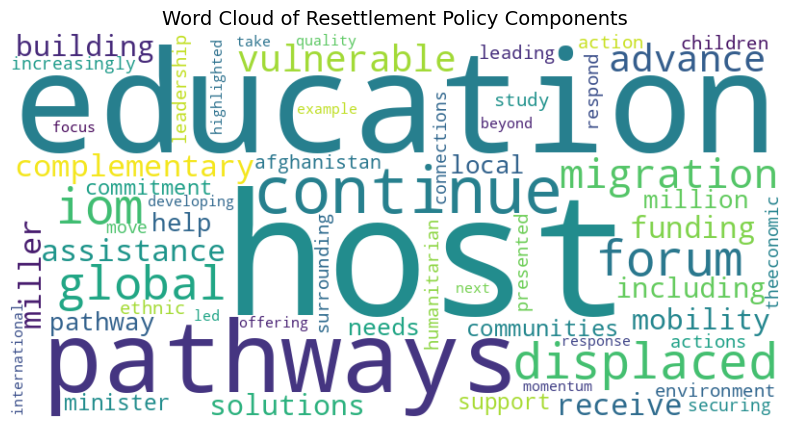

In [ ]:
from wordcloud import WordCloud

# Put all rows into one row within a dataframe form
text = ' '.join(resettlement_ircc_df['Full_Text'].apply(lambda x: ' '.join(x)))
new_resettlement_df = pd.DataFrame({'text': [text]})

doc_idx = len(new_resettlement_df)-1

# Create a dictionary of terms and their summed TF-IDF scores
wc_data = dict(top_tfidf_terms_for_doc(doc_idx, top_n=60))

# Create the word cloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(wc_data)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Resettlement Policy Components", fontsize=14)
plt.show()



## 4 Discussions


### 4.1 Policy Analyses

**4.1.1** Canadian Immigration Policies' Responsiveness to Different Xonflicts

The temporal line charts show that the keyword “refugees” exhibits continuous and frequent fluctuations from 2019 to 2025, indicating that refugee-related issues remain a central focus in IRCC’s official discourse. Beginning in mid-2021, and especially from late 2021 to early 2022, the term displays a series of sharp and concentrated peaks. These peaks closely align with the timing of the Afghanistan crisis and the outbreak of the conflict in Ukraine. Consistent with this pattern, the terms “afghanistan” and “ukraine” remain near zero for most of the period but rise dramatically immediately after each respective crisis, reinforcing the earlier conclusion that IRCC’s humanitarian messaging responds directly to major global conflicts.

The prominence of “ukraine” is particularly notable. After its initial surge in early 2022, the term continues to show distinct high points into early 2023 and again in late 2024 to early 2025. This suggests that IRCC’s communication regarding the Ukraine crisis remained strong not only at the moment of the conflict’s outbreak but also intermittently throughout the following years. By contrast, the term “afghanistan” reaches its highest peak around mid-2021 and early 2022. Although smaller peaks appear later—such as in early 2023—the overall intensity and duration are more concentrated in the immediate aftermath of the crisis. This pattern is consistent with existing literature that highlights the selective and time-limited nature of Canada’s responses.

Attention to “gaza” emerges only at the end of 2023. Despite a few sharp peaks in mid-2024 and early 2025, the overall level of prominence remains low. The delayed and limited discourse surrounding Gaza suggests that IRCC’s response was both narrow and infrequent, reflecting the influence of geopolitical considerations on Canada’s immigration and humanitarian communication.

**4.1.2** The Key Concerns of Resettlement Policy

The words “host” and “education” appear most frequently, suggesting that they are the core focuses of immigration settlement policies. The term “host” reflects a typical emergency response to temporary crises, such as the evacuation from Afghanistan or the war in Ukraine. It indicates that an important immediate settlement policy for refugees entering Canada is temporary hosting in private homes. This policy is low-cost but shows that the government relies on communities and private individuals to quickly address the housing needs caused by large population inflows.

The frequent mention of “education” suggests that the government is not only concerned with the current survival of refugees but also with the development of the next generation and their future contributions to society. Education is key to social mobility, and its frequent appearance demonstrates the policy’s forward-looking nature. This aligns with the less frequent use of the word “children,” reflecting a humanistic approach in settlement policies.

The relatively low frequency of “mobility” is a noticeable blind spot. Refugees are often concentrated in large cities like Toronto and Vancouver, creating pressure on local resources. Insufficient attention to “mobility” may indicate that policies do not strongly encourage refugees to settle in medium or small cities. This could lead to continued stress on housing and employment markets in large cities. The term “funding” also appears relatively infrequently, which can be interpreted in two ways: first, the government may prefer to emphasize outcomes (like housing) rather than the costs of implementation; second, the available funding may not be sufficient to meet all settlement needs, so it is mentioned less often.

Finally, the word “communities” likely shows that efforts to promote community integration do exist. However, the word cloud does not show much attention to “employment,” which could be an area for future settlement policies to consider.

### 4.2 Limitations and Further Research

This study is based on official press releases from IRCC, which are the government’s main tools for managing public expectations, promoting policy achievements, and demonstrating positive actions.

The analysis results, such as the high frequency of references to “education,” reflect what the government wants the public to know, rather than the actual resources or services received by refugees. Press releases may tend to overemphasize successful aspects while downplaying or avoiding issues such as bureaucracy, delays, or funding gaps in policy implementation. In addition, the study does not include the perspectives of refugees, settlement agencies, or frontline staff, which creates blind spots regarding the practical challenges of the policies, their effectiveness, and the real needs of refugees, such as mental health or trauma recovery.

There are also limitations in the research method. Word clouds and TF-IDF are quantitative analyses at the vocabulary level, which cannot capture the emotional tone, intensity, or complex negation in the text. For example, the high-frequency word “housing” may appear in positive contexts like “housing needs have been successfully met” or in negative contexts like “housing shortages remain a major challenge”. Low-frequency words, such as “mobility” and “funding,” may be mentioned less in press releases but can be crucial in key implementation processes or internal discussions. Simple word frequency analysis may therefore underestimate the actual impact of these structural or administrative terms.

Based on these limitations, future research should shift the focus from “what the government says” to “how policies are actually implemented.” For example, one could quantitatively compare the TF-IDF scores or word frequencies of settlement-related keywords (such as host and education) with the government’s actual project budget and spending during the same period. Researchers could also examine how often local government reports mention real issues, like housing shortages. If local reports frequently highlight these challenges while IRCC communications remain quiet, it would strongly suggest gaps in IRCC’s communication or policy in addressing regional pressures.

## 5. Conclusion

In conclusion, IRCC has maintained long-term attention to global conflicts and refugee issues. At the policy level, the government’s communication mechanism allows it to respond quickly to most major external geopolitical events.
However, this response is not always balanced. For example, discussions of the Ukraine crisis are not only intense but also sustained into 2023 and beyond, reflecting both political sensitivity and a long-term commitment to the European crisis. In contrast, discussions about Afghanistan, while initially strong, peaked over a relatively short period. This difference aligns with the selective and time-limited response patterns noted in the existing literature. References to Gaza only appear at the end of 2023, with overall low intensity and sparse frequency. This delay and limited attention highlight that Canada’s humanitarian communication in immigration policy is largely influenced by geopolitical considerations, indicating that the government exercises caution when deciding which conflicts to respond to and discuss publicly.
Word cloud analysis shows that “host” and “education” are the central focuses in settlement policy discourse. The low frequency of “mobility” likely reflects a current policy challenge to be solved, which exacerbates housing and employment pressures in major cities such as Toronto and Vancouver. Overall, Canada’s immigration policy responses to refugees are consistent with the viewpoints discussed in the previous review. Nevertheless, the current analysis has some limitations and gaps, and future research could combine these findings with actual policy reports and refugee population data for a more comprehensive understanding.


# The part using Generative AI (Google Gemini):

1. **Input: Please help me improve this code by finding out the overlapped contents (using English, please):**
the original code:

```
# Scrape text from collected article links: define the scraping action first

def get_article_text_from_link(row):


# Choose a URL to scrape: try the live df first, fallback to offline_df if needed.

article_url = row['Link']


# Send a GET request to retrieve the raw HTML of the page.

page_resp = requests.get(article_url, timeout=15)


# Create a BeautifulSoup object to parse the HTML document.

soup_text = BeautifulSoup(page_resp.text, "html.parser")


# Find all paragraph tags <p> and extract text from each.

ircc_content = soup_text.find_all('div', class_='cmp-text')

if not ircc_content:

return 'CONTENT_NOT_FOUND'

paragraphs = ircc_content[0].find_all('p')


# Use a list comprehension to strip whitespace and only keep non-empty paragraphs.

para_text = [row.get_text(strip=True) for row in paragraphs if row.get_text(strip=True)]


# Join paragraphs into a single string for quick inspection.

full_text = " ".join(para_text)
print("First 500 characters of extracted text:\n")

print(full_text[:500])

return full_text


# Apply to whole df

ircc_news_df['Full_Text'] = ircc_news_df.apply(get_article_text_from_link, axis=1)


# Display the first few entries of the new column to confirm creation

print("First 500 characters of extracted text for first few articles:")

for i, text in enumerate(ircc_news_df['Full_Text'].head()):

if text is not None:
soup = BeautifulSoup(text)
article = soup.get_text()

print(f"Article {i}: {article[:500]}...")

else:
print(f"Article {i}: CONTENT_NOT_FOUND")

```

**Output from Google Gemini**:

🔍 Identifying Overlapped Content and Potential Improvements

The provided Python code snippet is designed to **scrape text content** from a list of URLs in a DataFrame (`ircc_news_df`).

The part of your code that contains **overlapped content** or redundant operations is the **text processing/extraction logic** applied *inside* the function and *outside* of it.

### 1\. ♻️ Redundant Text Processing

The most significant overlap is the repeated use of `BeautifulSoup` to process the text.

| Location | Action | Overlap/Redundancy |
| :--- | :--- | :--- |
| **Inside** `get_article_text_from_link` | `full_text = " ".join(para_text)` | Joins the clean text into a single string. This is the intended output. |
| **Outside** the function (in the print loop) | `soup = BeautifulSoup(text)` and `article = soup.get_text()` | The text returned by the function (`text`) is already a **clean string** (`full_text`). It should not contain any HTML tags, as they were stripped earlier by `row.get_text(strip=True)`. Applying `BeautifulSoup` again here is **unnecessary** and redundant, as the variable `text` already holds the clean, joined text. |

**Goal:** The final `Full_Text` column should contain only the clean article text.

### 2\. 📝 Code Smell/Minor Overlap

  * **HTML Parsing Variable Names:** Inside the function, you use `soup_text` for the initial full page parse and later you use `soup = BeautifulSoup(text)` outside the function. While the variables are local/scoped, reusing `BeautifulSoup` is a logical overlap.

### 3\. 💡 Recommended Improvements

To improve the code, you should remove the unnecessary re-parsing step at the end:

In [ ]:
# The function part is fine, as it returns clean text.
# ... (code for get_article_text_from_link remains the same)
# ...

ircc_news_df['Full_Text'] = ircc_news_df.apply(get_article_text_from_link, axis=1)

# Display the first few entries of the new column to confirm creation
print("First 500 characters of extracted text for first few articles:")

# --- 🚀 IMPROVED CODE STARTS HERE ---
# **Remove the redundant BeautifulSoup step**
for i, text in enumerate(ircc_news_df['Full_Text'].head()):
    if text is not None and text != 'CONTENT_NOT_FOUND':
        # 'text' is already the clean article text, so use it directly.
        print(f"Article {i}: {text[:500]}...")
    else:
        # Check for 'CONTENT_NOT_FOUND' specifically for clearer output.
        print(f"Article {i}: {text if text else 'ERROR/NONE'}")
# --- 🚀 IMPROVED CODE ENDS HERE ---